# **Assignment 5: Logistic Regression on Pima Indians Diabetes Dataset**

This notebook demonstrates binary classification using Logistic Regression on the Pima Indians Diabetes dataset. It covers data preparation, model training, prediction, and evaluation with confusion matrix, precision, recall, and F1-score.

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import pandas as pd

### **Dataset Selection: Pima Indians Diabetes Dataset**

For this task, we will use the Pima Indians Diabetes dataset. This dataset is well-suited for binary classification as it aims to predict whether a patient has diabetes based on various diagnostic measurements. It is publicly available and widely used for educational purposes.

You can find more information about this dataset on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/pima+indians+diabetes) or various other data science platforms.

### **Data Preparation: Defining Features and Target, Splitting Data**

Before training our logistic regression model, we need to separate the dataset into features (X) and the target variable (y). The 'Outcome' column represents whether a patient has diabetes (1) or not (0), making it our target variable. All other columns will be used as features.

After defining X and y, we will split the data into training and testing sets. This allows us to train the model on a portion of the data and evaluate its performance on unseen data, which is crucial for assessing its generalization ability.

In [2]:
df = pd.read_csv("diabetes.csv")

df.isnull().sum()

# Define features (X) and target (y)
X = df.drop('Outcome', axis=1)  # Features are all columns except 'Outcome'
y = df['Outcome']                # Target is the 'Outcome' column

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Display the first few rows of X and y
print("\nFirst 5 rows of Features (X):")
display(X.head())
print("\nFirst 5 rows of Target (y):")
display(y.head())

Features (X) shape: (768, 8)
Target (y) shape: (768,)

First 5 rows of Features (X):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33



First 5 rows of Target (y):


0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [3]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# We'll use a test size of 20% and a random state for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


### **Model Training: Logistic Regression**

Now, we will train a Logistic Regression model using the `X_train` and `y_train` datasets. Logistic Regression is a statistical model that in its basic form uses a logistic function to model a binary dependent variable, making it suitable for our binary classification task (diabetes or no diabetes).

In [4]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# We'll use a solver that is robust and often recommended for general use cases.
# random_state is set for reproducibility.
model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### **Prediction on Test Data**

After training, we will use the trained model to make predictions on the `X_test` dataset. These predictions (`y_pred`) will then be compared against the actual `y_test` values to evaluate the model's performance.

In [5]:
# Make predictions on the test set
y_pred = model.predict(X_test)

print(f"Shape of predictions: {y_pred.shape}")
print("First 10 predictions:")
print(y_pred[:10])
print("\nFirst 10 actual values (y_test):")
print(y_test[:10].values)

Shape of predictions: (154,)
First 10 predictions:
[0 0 0 0 0 0 0 1 1 1]

First 10 actual values (y_test):
[0 0 0 0 0 0 0 0 0 0]


### **Model Evaluation: Confusion Matrix, Precision, Recall, and F1-Score**

To thoroughly evaluate our binary classification model, we will use several key metrics:

*   **Confusion Matrix**: A table that describes the performance of a classification model on a set of test data for which the true values are known. It shows the number of true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN).
*   **Precision**: The ratio of correctly predicted positive observations to the total predicted positive observations. High precision relates to a low false positive rate.
*   **Recall (Sensitivity)**: The ratio of correctly predicted positive observations to all observations in the actual class. High recall relates to a low false negative rate.
*   **F1-Score**: The weighted average of Precision and Recall. It tries to find the balance between precision and recall, and is particularly useful when you have an uneven class distribution.

Confusion Matrix:
[[83 16]
 [21 34]]

Precision: 0.6800
Recall: 0.6182
F1-Score: 0.6476


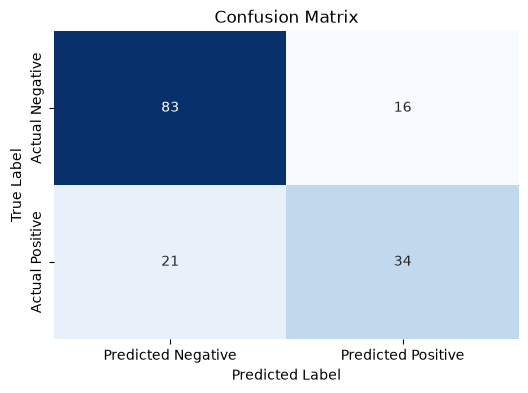

In [6]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate Precision, Recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()